In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
prices = pd.read_csv(
    "../data/raw/sp500_stocks.csv",
    index_col=0,
    parse_dates=True
)

market = pd.read_csv(
    "../data/raw/sp500_index.csv",
    index_col=0,
    parse_dates=True
)

rf = pd.read_csv(
    "../data/raw/risk_free.csv",
    index_col=0,
    parse_dates=True
)

capm = pd.read_csv("../data/processed/capm_results.csv")

In [3]:
daily_returns = prices.pct_change().dropna()

annual_returns = (
    (1 + daily_returns).prod() **
    (252 / len(daily_returns))
) - 1

In [4]:
market_daily = market.pct_change().dropna()

market_return = (
    (1 + market_daily.iloc[:, 0]).prod() **
    (252 / len(market_daily))
) - 1

print(market_return)

0.11654644314601392


In [5]:
rf = rf / 100

annual_rf = rf.mean().iloc[0]

print(annual_rf)

0.01963737698256034


In [6]:
capm["Expected Return"] = (
    annual_rf +
    capm["Beta"] *
    (market_return - annual_rf)
)

In [7]:
capm["Actual Return"] = (
    annual_returns
    .reindex(capm["Stock"])
    .values
)

In [8]:
capm["Pricing Error"] = (
    capm["Actual Return"] -
    capm["Expected Return"]
)

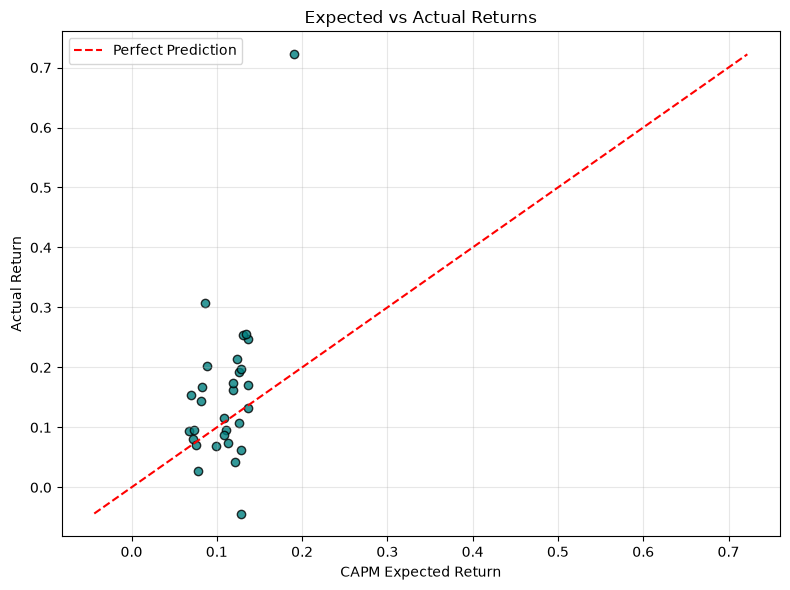

In [9]:
plt.figure(figsize=(8,6))

plt.scatter(
    capm["Expected Return"],
    capm["Actual Return"],
    color="teal",
    edgecolors="black",
    alpha=0.8
)

lims = [
    min(capm["Expected Return"].min(), capm["Actual Return"].min()),
    max(capm["Expected Return"].max(), capm["Actual Return"].max())
]

plt.plot(lims, lims, "r--", label="Perfect Prediction")

plt.xlabel("CAPM Expected Return")
plt.ylabel("Actual Return")
plt.title("Expected vs Actual Returns")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
capm.sort_values(
    "Pricing Error",
    ascending=False
)[
    ["Stock",
     "Sector",
     "Expected Return",
     "Actual Return",
     "Pricing Error"]
]

,Stock,Sector,Expected Return,Actual Return,Pricing Error
20,NVDA,Information Technology,0.190091,0.722096,0.532005
15,LLY,Health Care,0.086567,0.306586,0.220019
9,GOOGL,Communication Services,0.130241,0.253727,0.123486
19,MSFT,Information Technology,0.134485,0.256446,0.121961
5,COST,Consumer Staples,0.087953,0.202885,0.114932
0,AAPL,Information Technology,0.136249,0.247082,0.110833
3,CAT,Industrials,0.123535,0.213204,0.089669
28,WMT,Consumer Staples,0.069734,0.154187,0.084453
1,ABBV,Health Care,0.082932,0.167341,0.084409
16,MA,Financials,0.128826,0.197320,0.068494
